In [1]:
import numpy as np 
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

In [2]:
X_train = pd.read_csv("../Data/X_train.csv")
X_test = pd.read_csv("../Data/X_test.csv")

y_train = pd.read_csv("../Data/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/y_test.csv").squeeze()


In [3]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [4]:
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [5]:
y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1,1))

In [6]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=1000
)

xgb_model.fit(X_train_scaled, y_train_scaled)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
y_train_pred_scaled = xgb_model.predict(X_train_scaled)
y_test_pred_scaled = xgb_model.predict(X_test_scaled)

In [8]:
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1,1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1,1)).ravel()

In [9]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

In [10]:
r2_test = r2_score(y_test,y_test_pred)
mae_test = mean_absolute_error(y_test,y_test_pred)
mse_test = mean_squared_error(y_test,y_test_pred)
rmse_test = root_mean_squared_error(y_test,y_test_pred)

In [ ]:
print(f"R2:   {r2_test:.3f}")
print(f"MAE:  {mae_test:.3f} dB")
print(f"MSE:  {mse_test:.3f} dB2")
print(f"RMSE: {rmse_test:.3f} dB")

R²:   0.957
MAE:  1.072 dB
MSE:  2.130 dB²
RMSE: 1.459 dB


In [12]:
r2_train = r2_score(y_train,y_train_pred)
mae_train = mean_absolute_error(y_train,y_train_pred)
mse_train = mean_squared_error(y_train,y_train_pred)
rmse_train = root_mean_squared_error(y_train,y_train_pred)

In [13]:
results = pd.DataFrame({
    "Metric": ["R2","MAE","MSE","RMSE"],
    "Train": [r2_train,mae_train,mse_train,rmse_train],
    "Test": [r2_test,mae_test,mse_test,rmse_test]
})

results

,Metric,Train,Test
0,R2,0.997563,0.957042
1,MAE,0.235338,1.071541
2,MSE,0.113790,2.129672
3,RMSE,0.337328,1.459339


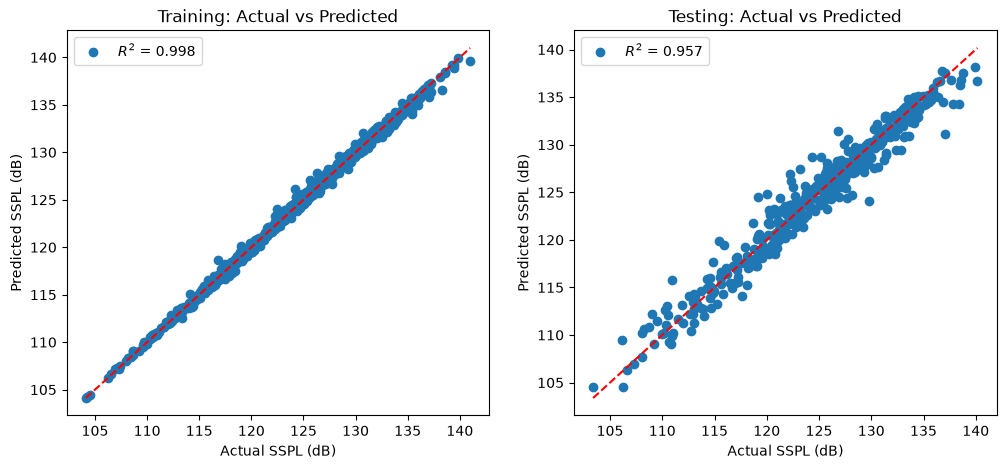

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_train, y_train_pred,label=f"$R^2$ = {r2_train:.3f}")
ax2.scatter(y_test, y_test_pred , label=f"$R^2$ = {r2_test:.3f}")

ax1.set_xlabel("Actual SSPL (dB)")
ax1.set_ylabel("Predicted SSPL (dB)")
ax1.set_title("Training: Actual vs Predicted")

low = min(y_train.min(), y_train_pred.min())
high = max(y_train.max(), y_train_pred.max())


ax1.plot([low, high], [low, high], linestyle="--", color="red")

ax2.set_xlabel("Actual SSPL (dB)")
ax2.set_ylabel("Predicted SSPL (dB)")
ax2.set_title("Testing: Actual vs Predicted")

low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())

ax2.plot([low, high], [low, high], linestyle="--", color="red")

ax1.legend()
ax2.legend()

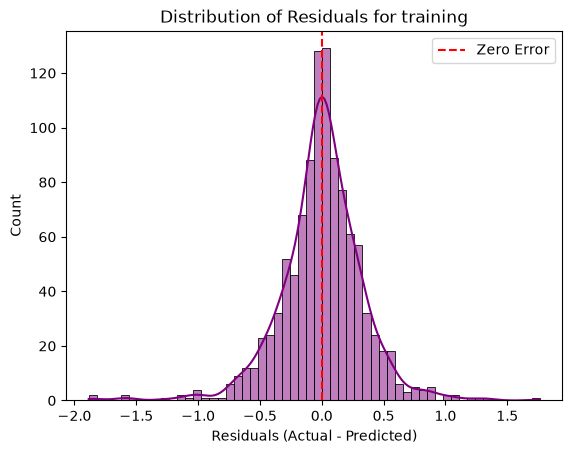

In [15]:
import seaborn as sns 
train_residuals = y_train - y_train_pred
sns.histplot(train_residuals,kde=True,color="purple")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error") # reference line
plt.title("Distribution of Residuals for training")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.show()

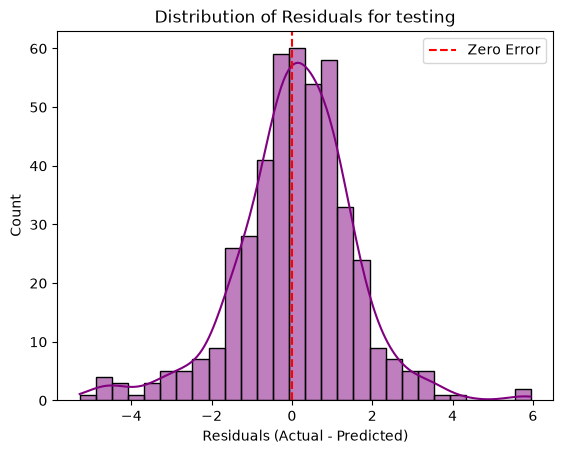

In [16]:
import seaborn as sns 
test_residuals = y_test - y_test_pred
sns.histplot(test_residuals,kde=True,color="purple")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error") # reference line
plt.title("Distribution of Residuals for testing")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.show()

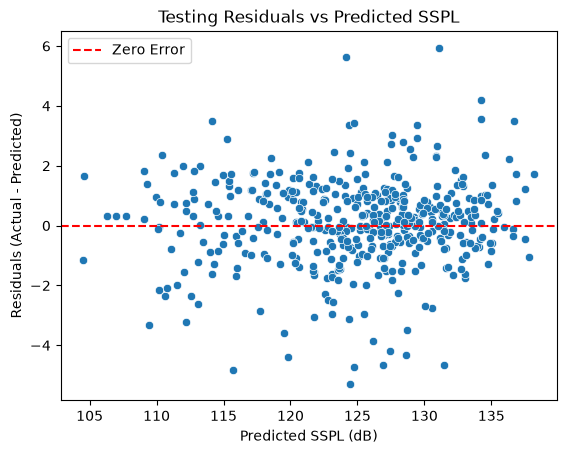

In [17]:
test_residuals = y_test - y_test_pred

sns.scatterplot(
    x=y_test_pred,
    y=test_residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="Zero Error"
)

plt.title("Testing Residuals vs Predicted SSPL")
plt.xlabel("Predicted SSPL (dB)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.show()

In [18]:
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [19]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=1000,
    tree_method="hist"
)
xgb_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("xgb", xgb_model)
])

search_space = {
    "xgb__n_estimators": Integer(50, 500),
    "xgb__max_depth": Integer(2, 10),

    "xgb__learning_rate": Real(
        0.01,
        0.3,
        prior="log-uniform"
    ),

    "xgb__gamma": Real(0.0, 5.0),
    "xgb__reg_alpha": Real(0.0, 1.0),
    "xgb__reg_lambda": Real(0.0, 5.0),

    "xgb__subsample": Real(0.5, 1.0),
    "xgb__colsample_bytree": Real(0.5, 1.0)
}

In [ ]:
bayes_search = BayesSearchCV(
    estimator=xgb_pipeline,
    search_spaces=search_space,
    n_iter=30,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    refit=True,
    random_state=1000,
    verbose=1
)

bayes_search.fit(X_train, y_train)



Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

np.float64(0.9372778878731636)

In [21]:
bayes_search.best_params_

OrderedDict([('xgb__colsample_bytree', 1.0),
             ('xgb__gamma', 0.0),
             ('xgb__learning_rate', 0.18995636512104455),
             ('xgb__max_depth', 6),
             ('xgb__n_estimators', 500),
             ('xgb__reg_alpha', 0.938535306447071),
             ('xgb__reg_lambda', 5.0),
             ('xgb__subsample', 0.6470188993632964)])

In [22]:
from sklearn.model_selection import cross_validate
import pandas as pd

cv_scores = cross_validate(
    bayes_search.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error"
    ),
    return_train_score=True
)

In [26]:
cross_val_results = pd.DataFrame({
    "R2": cv_scores["test_r2"],
    "MAE": -cv_scores["test_neg_mean_absolute_error"],
    "MSE": -cv_scores["test_neg_mean_squared_error"],
    "RMSE": -cv_scores["test_neg_root_mean_squared_error"]
})

cross_val_results.index = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5"
]

cross_val_results

,R2,MAE,MSE,RMSE
Fold 1,0.941078,1.072987,2.792354,1.671034
Fold 2,0.910773,1.154093,3.594223,1.895844
Fold 3,0.944001,1.083322,2.693068,1.641057
Fold 4,0.935886,1.163207,3.065450,1.750843
Fold 5,0.954651,0.999668,2.166381,1.471863


In [27]:
summary_results = pd.DataFrame({
    "Mean": cross_val_results.mean(),
    "Std": cross_val_results.std()
})

summary_results

,Mean,Std
R2,0.937278,0.016324
MAE,1.094655,0.066807
MSE,2.862295,0.523167
RMSE,1.686128,0.155191
